# 05 - EDA Features


# Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs('../reports/figures/features', exist_ok=True)

df = pd.read_csv('../data/processed/featured_dataset.csv')

with open('../config/feature_sets.json', 'r') as f:
    feature_sets = json.load(f)

audio_features = feature_sets['audio_features']
full_features = feature_sets['full_features']

print('shape:', df.shape)
print('audio features:', len(audio_features))
print('full features:', len(full_features))

shape: (88167, 32)
audio features: 11
full features: 21


# Section 1 - New Feature Distributions

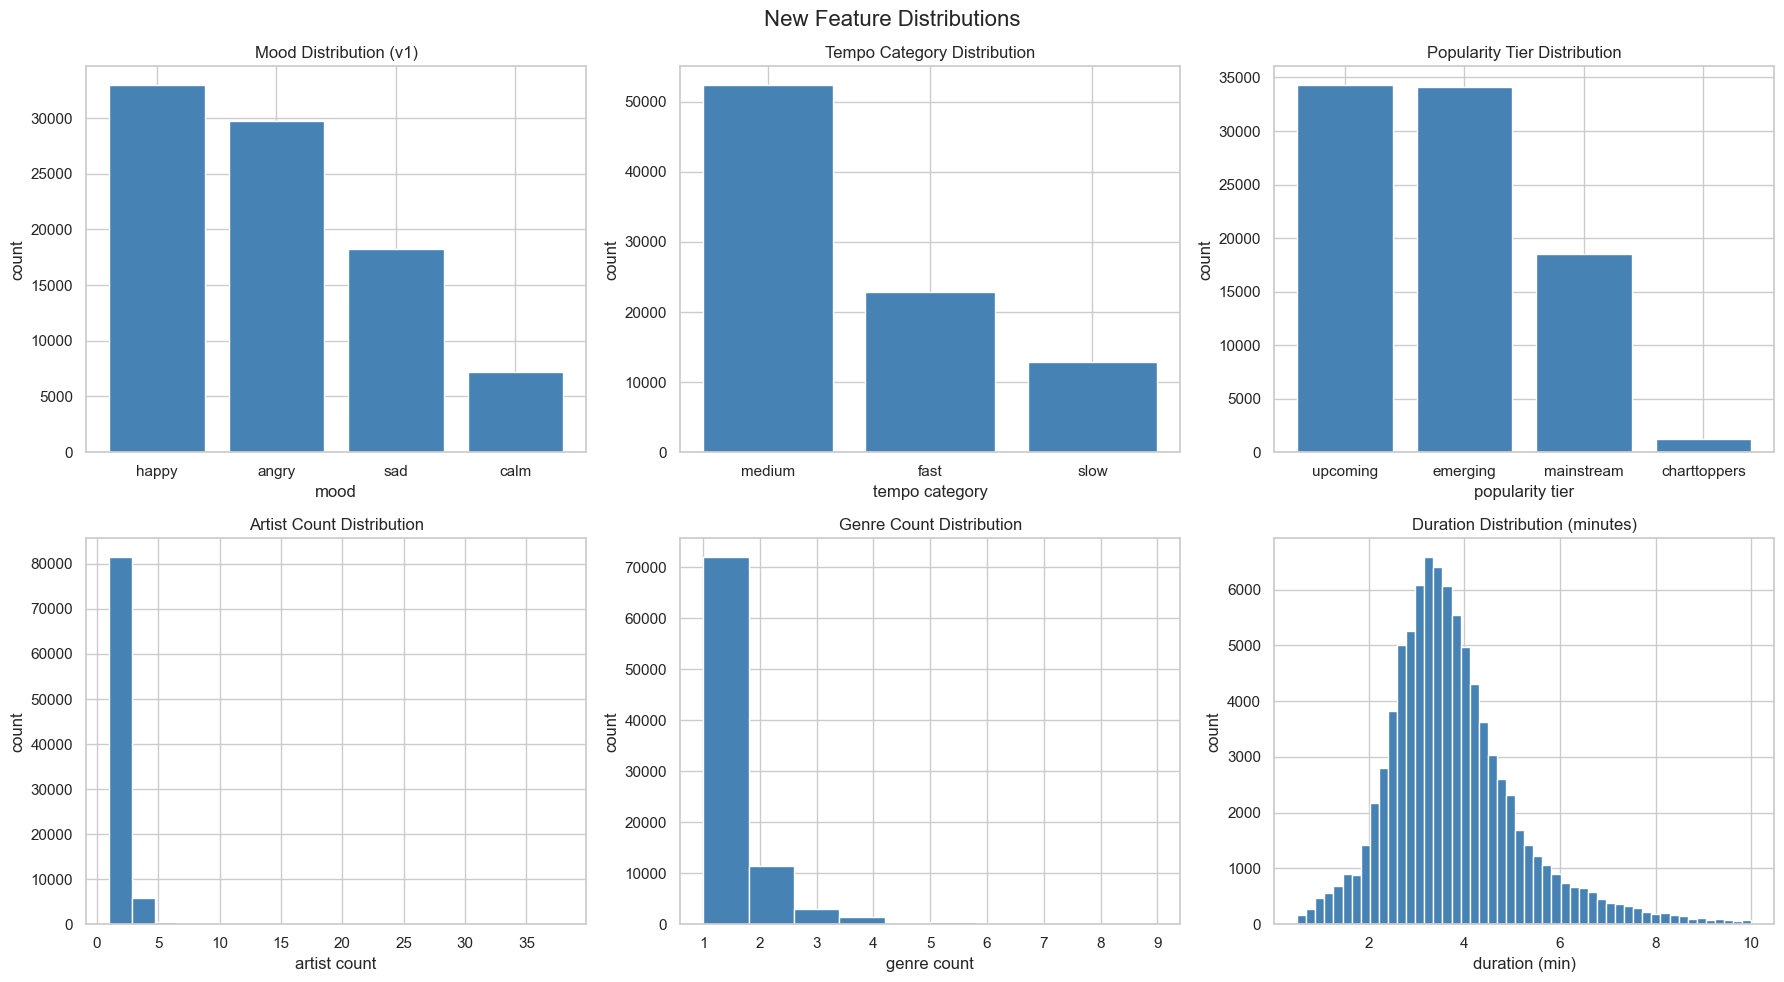

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# mood distribution
mood_counts = df['mood'].value_counts()
axes[0].bar(mood_counts.index, mood_counts.values, color='steelblue')
axes[0].set_title('Mood Distribution (v1)')
axes[0].set_xlabel('mood')
axes[0].set_ylabel('count')

# tempo category
tempo_counts = df['tempo_category'].value_counts()
axes[1].bar(tempo_counts.index, tempo_counts.values, color='steelblue')
axes[1].set_title('Tempo Category Distribution')
axes[1].set_xlabel('tempo category')
axes[1].set_ylabel('count')

# popularity tier
pop_counts = df['popularity_tier'].value_counts()
axes[2].bar(pop_counts.index, pop_counts.values, color='steelblue')
axes[2].set_title('Popularity Tier Distribution')
axes[2].set_xlabel('popularity tier')
axes[2].set_ylabel('count')

# artist count
axes[3].hist(df['artist_count'], bins=20, color='steelblue', edgecolor='white')
axes[3].set_title('Artist Count Distribution')
axes[3].set_xlabel('artist count')
axes[3].set_ylabel('count')

# genre count
axes[4].hist(df['genre_count'], bins=10, color='steelblue', edgecolor='white')
axes[4].set_title('Genre Count Distribution')
axes[4].set_xlabel('genre count')
axes[4].set_ylabel('count')

# duration min
axes[5].hist(df['duration_min'], bins=50, color='steelblue', edgecolor='white')
axes[5].set_title('Duration Distribution (minutes)')
axes[5].set_xlabel('duration (min)')
axes[5].set_ylabel('count')

plt.suptitle('New Feature Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/new_feature_distributions.png', bbox_inches='tight')
plt.show()

# Section 2 - Combined Features Distributions

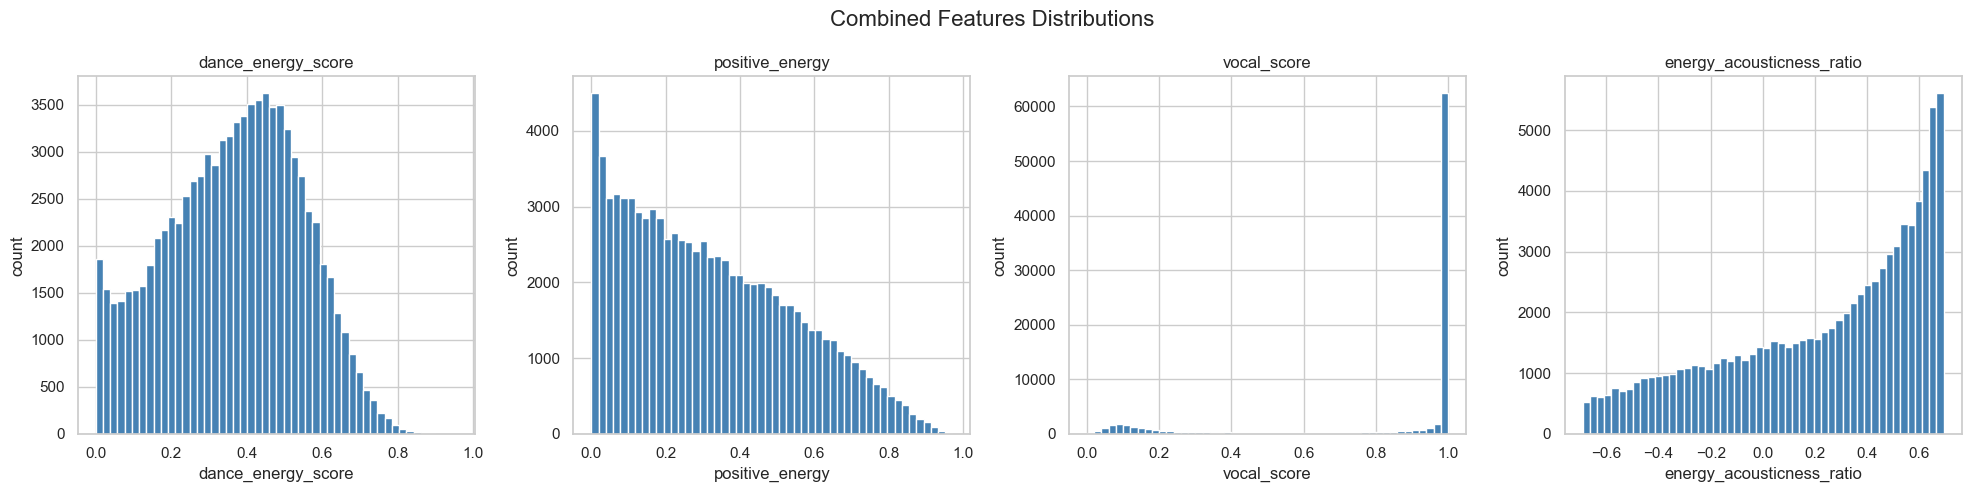

In [3]:
combined_features = ['dance_energy_score', 'positive_energy', 
                     'vocal_score', 'energy_acousticness_ratio']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(combined_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

plt.suptitle('Combined Features Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/combined_features_distributions.png', bbox_inches='tight')
plt.show()

# Section 3 - Mood v1 vs v2 Comparison

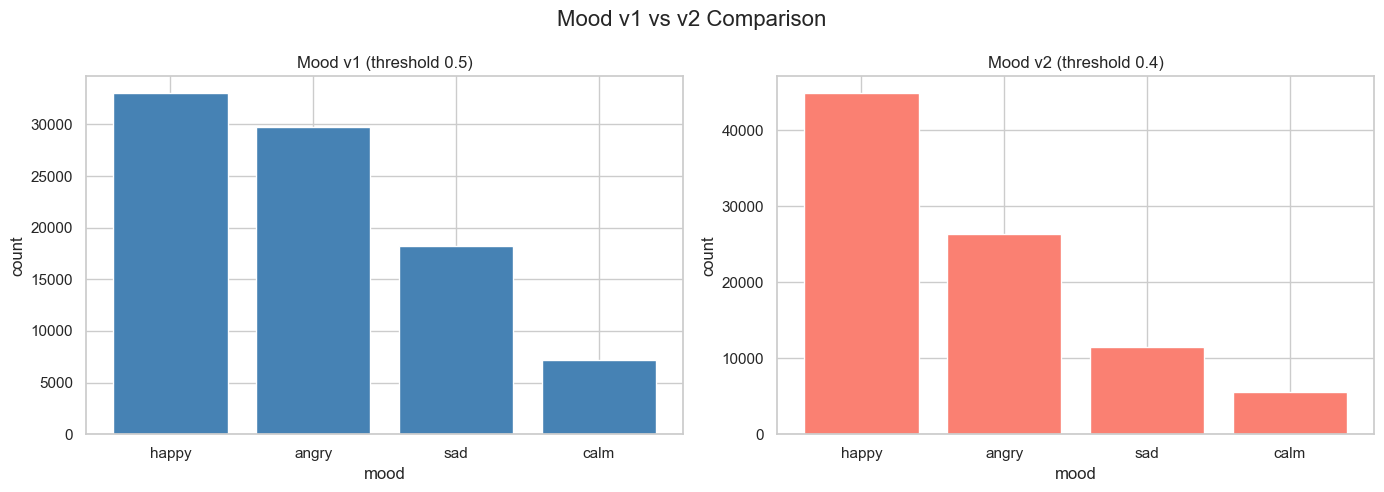

mood v1:
mood
happy    32992
angry    29754
sad      18252
calm      7169
Name: count, dtype: int64

mood v2:
mood_v2
happy    44808
angry    26282
sad      11528
calm      5549
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mood_v1 = df['mood'].value_counts()
mood_v2 = df['mood_v2'].value_counts()

axes[0].bar(mood_v1.index, mood_v1.values, color='steelblue')
axes[0].set_title('Mood v1 (threshold 0.5)')
axes[0].set_xlabel('mood')
axes[0].set_ylabel('count')

axes[1].bar(mood_v2.index, mood_v2.values, color='salmon')
axes[1].set_title('Mood v2 (threshold 0.4)')
axes[1].set_xlabel('mood')
axes[1].set_ylabel('count')

plt.suptitle('Mood v1 vs v2 Comparison', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/mood_comparison.png', bbox_inches='tight')
plt.show()

print('mood v1:')
print(mood_v1)
print('\nmood v2:')
print(mood_v2)

# Section 4 - New Features vs Popularity

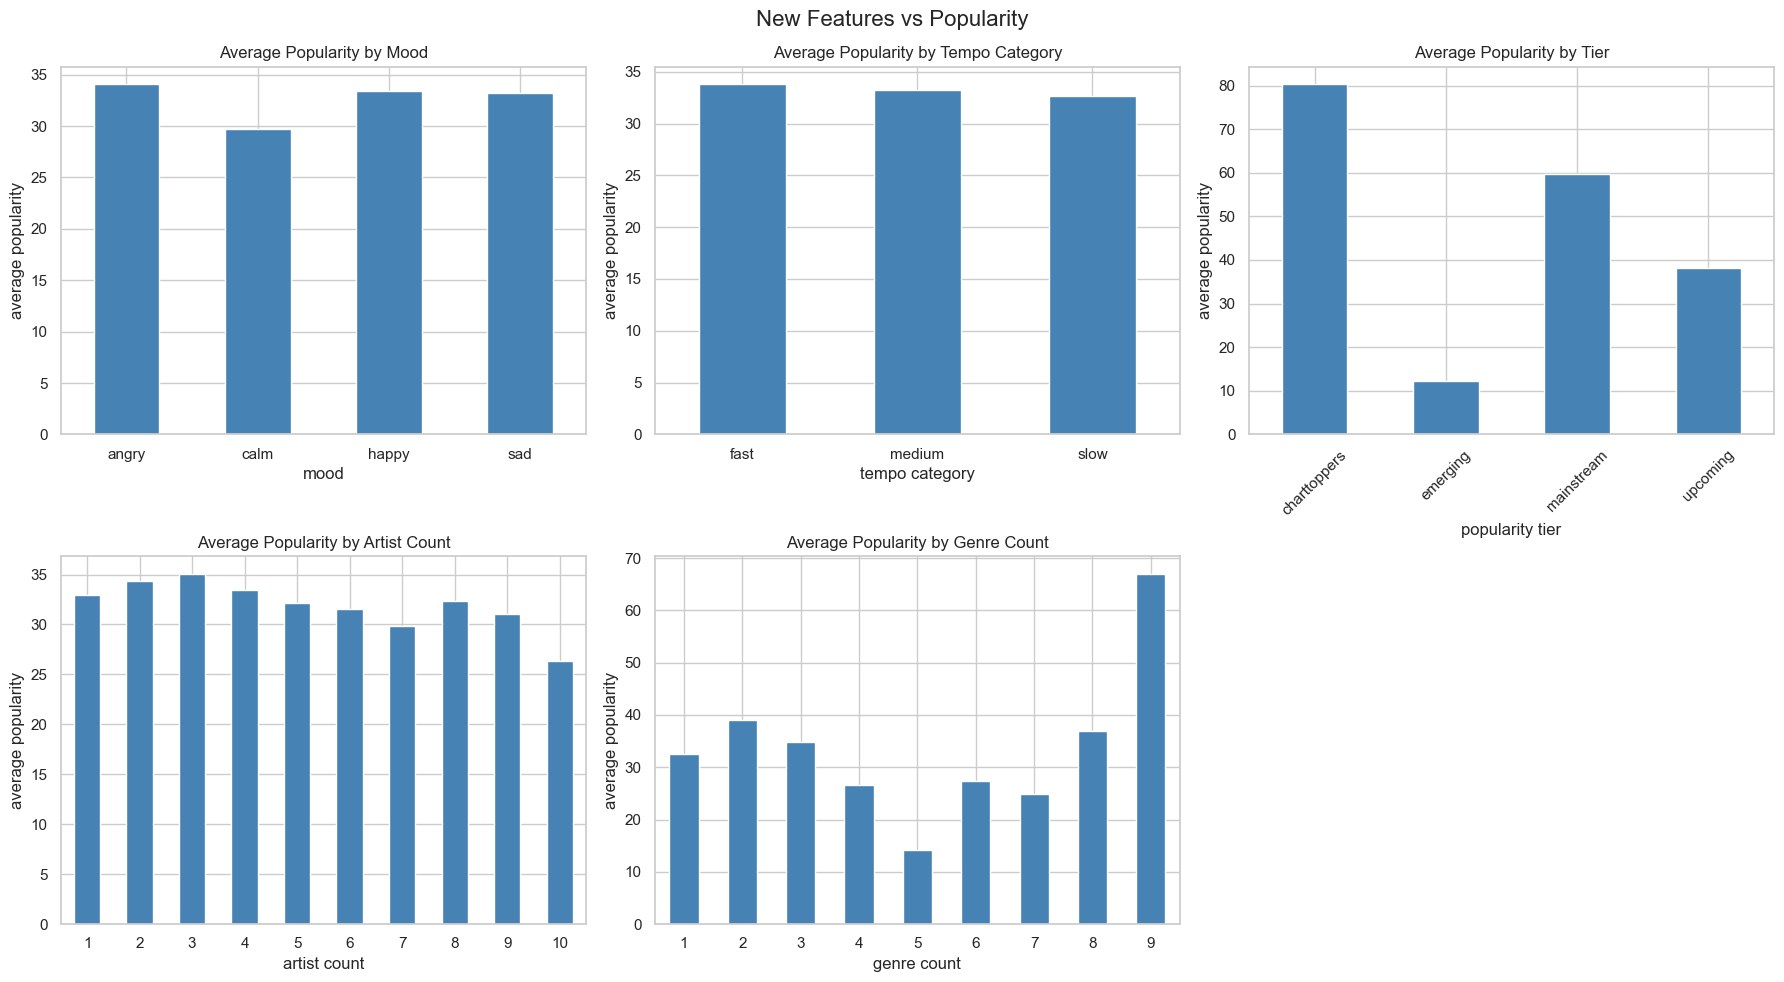

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# mood vs popularity
df.groupby('mood')['popularity'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Popularity by Mood')
axes[0].set_xlabel('mood')
axes[0].set_ylabel('average popularity')
axes[0].tick_params(axis='x', rotation=0)

# tempo category vs popularity
df.groupby('tempo_category')['popularity'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Popularity by Tempo Category')
axes[1].set_xlabel('tempo category')
axes[1].set_ylabel('average popularity')
axes[1].tick_params(axis='x', rotation=0)

# popularity tier vs popularity
df.groupby('popularity_tier')['popularity'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Average Popularity by Tier')
axes[2].set_xlabel('popularity tier')
axes[2].set_ylabel('average popularity')
axes[2].tick_params(axis='x', rotation=45)

# artist count vs popularity
df.groupby('artist_count')['popularity'].mean().head(10).plot(kind='bar', ax=axes[3], color='steelblue')
axes[3].set_title('Average Popularity by Artist Count')
axes[3].set_xlabel('artist count')
axes[3].set_ylabel('average popularity')
axes[3].tick_params(axis='x', rotation=0)

# genre count vs popularity
df.groupby('genre_count')['popularity'].mean().plot(kind='bar', ax=axes[4], color='steelblue')
axes[4].set_title('Average Popularity by Genre Count')
axes[4].set_xlabel('genre count')
axes[4].set_ylabel('average popularity')
axes[4].tick_params(axis='x', rotation=0)

axes[5].set_visible(False)

plt.suptitle('New Features vs Popularity', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/new_features_vs_popularity.png', bbox_inches='tight')
plt.show()

# Section 5 - Outliers in New Features

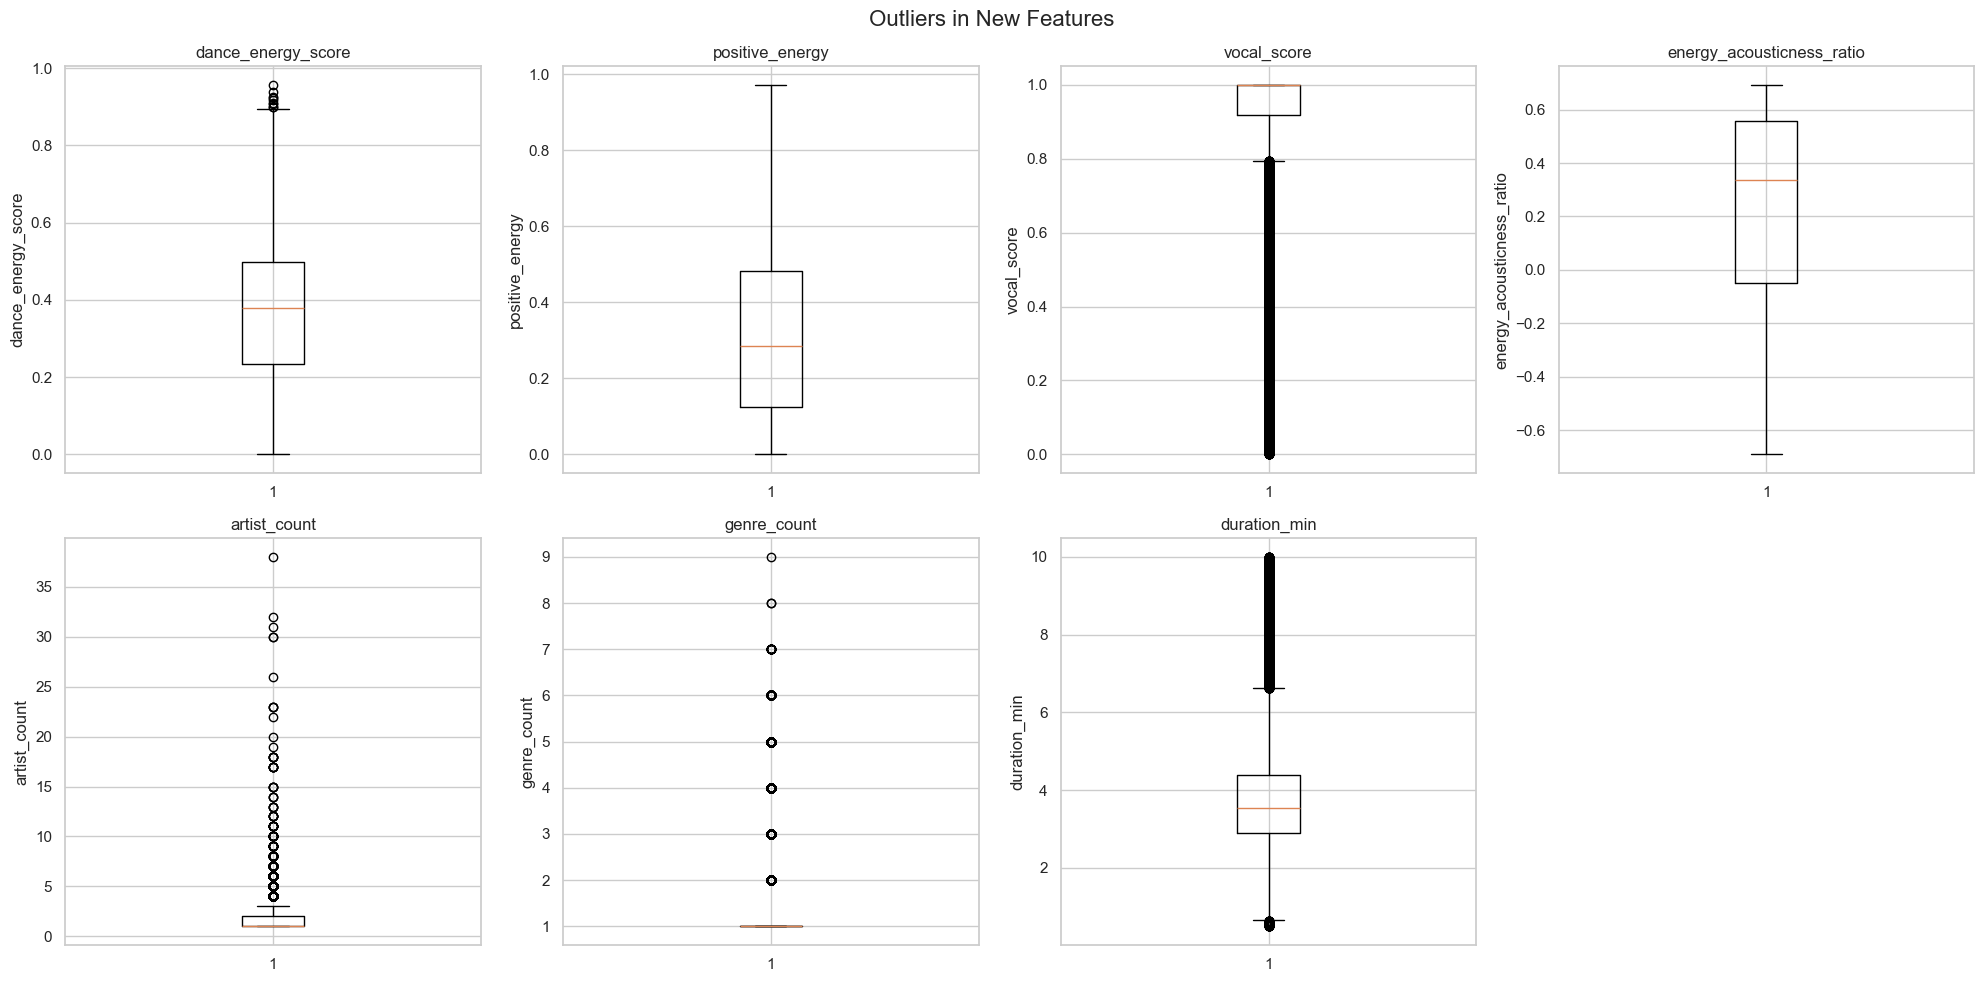

In [6]:
new_numeric = ['dance_energy_score', 'positive_energy', 
               'vocal_score', 'energy_acousticness_ratio',
               'artist_count', 'genre_count', 'duration_min']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(new_numeric):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)

plt.suptitle('Outliers in New Features', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/new_features_boxplots.png', bbox_inches='tight')
plt.show()

# Section 6 - Correlation of Full Feature Set

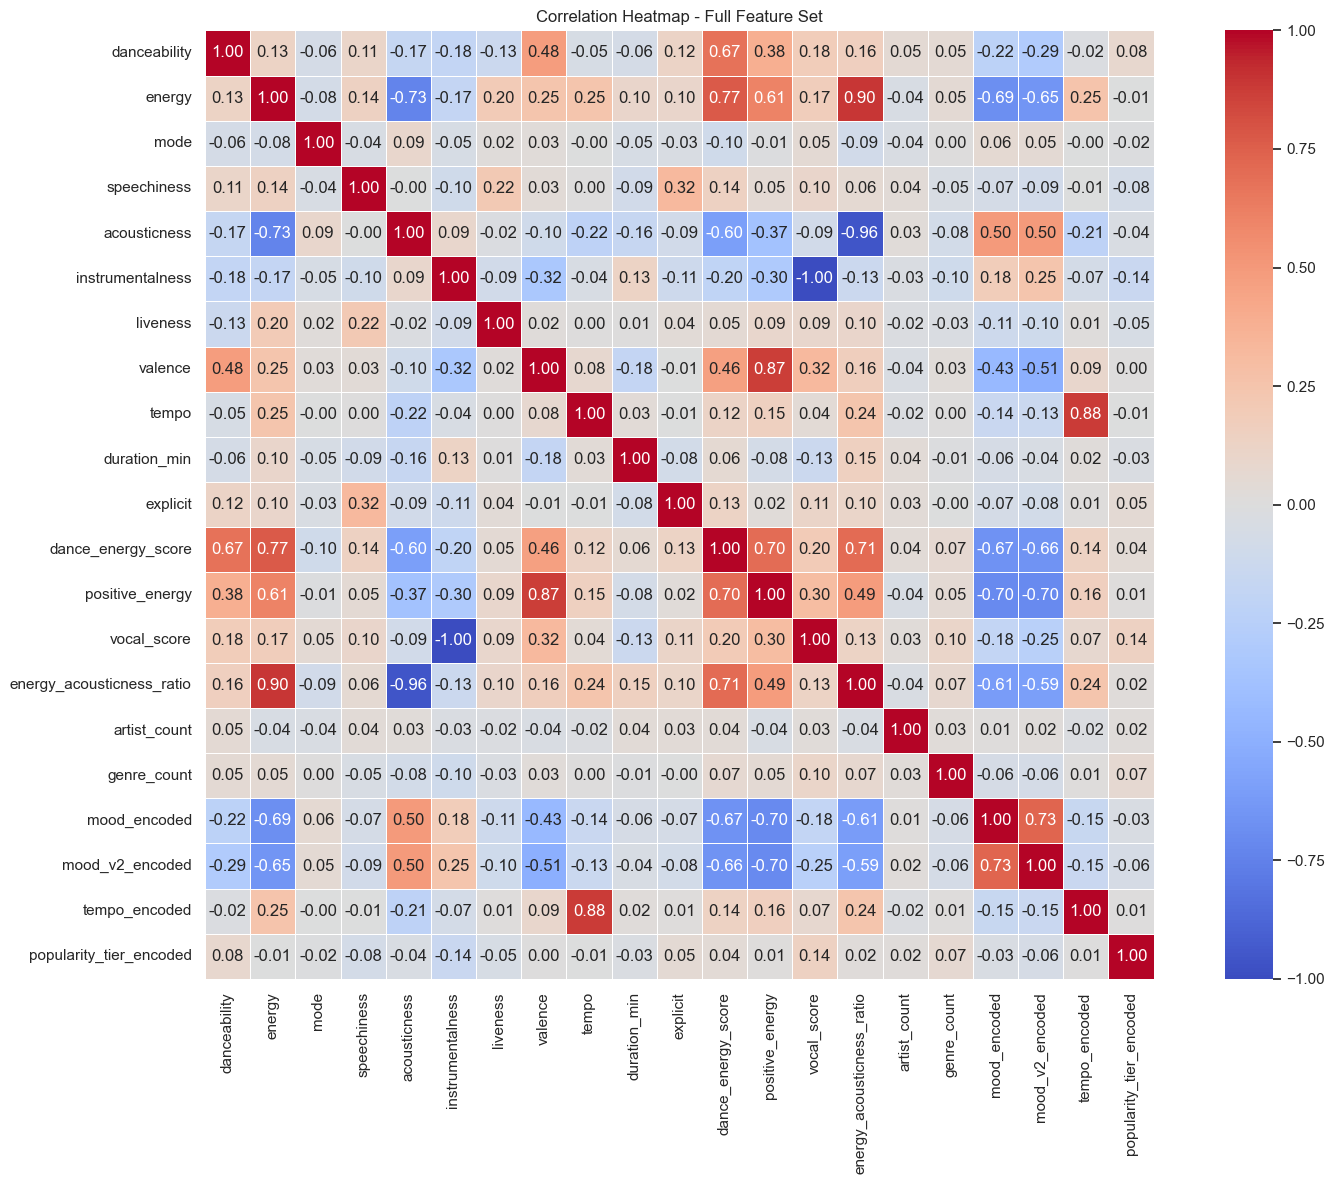

In [7]:
plt.figure(figsize=(16, 12))
corr_matrix = df[full_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Full Feature Set')
plt.tight_layout()
plt.savefig('../reports/figures/features/full_features_correlation.png', bbox_inches='tight')
plt.show()

# Section 7 - Feature Set Comparison

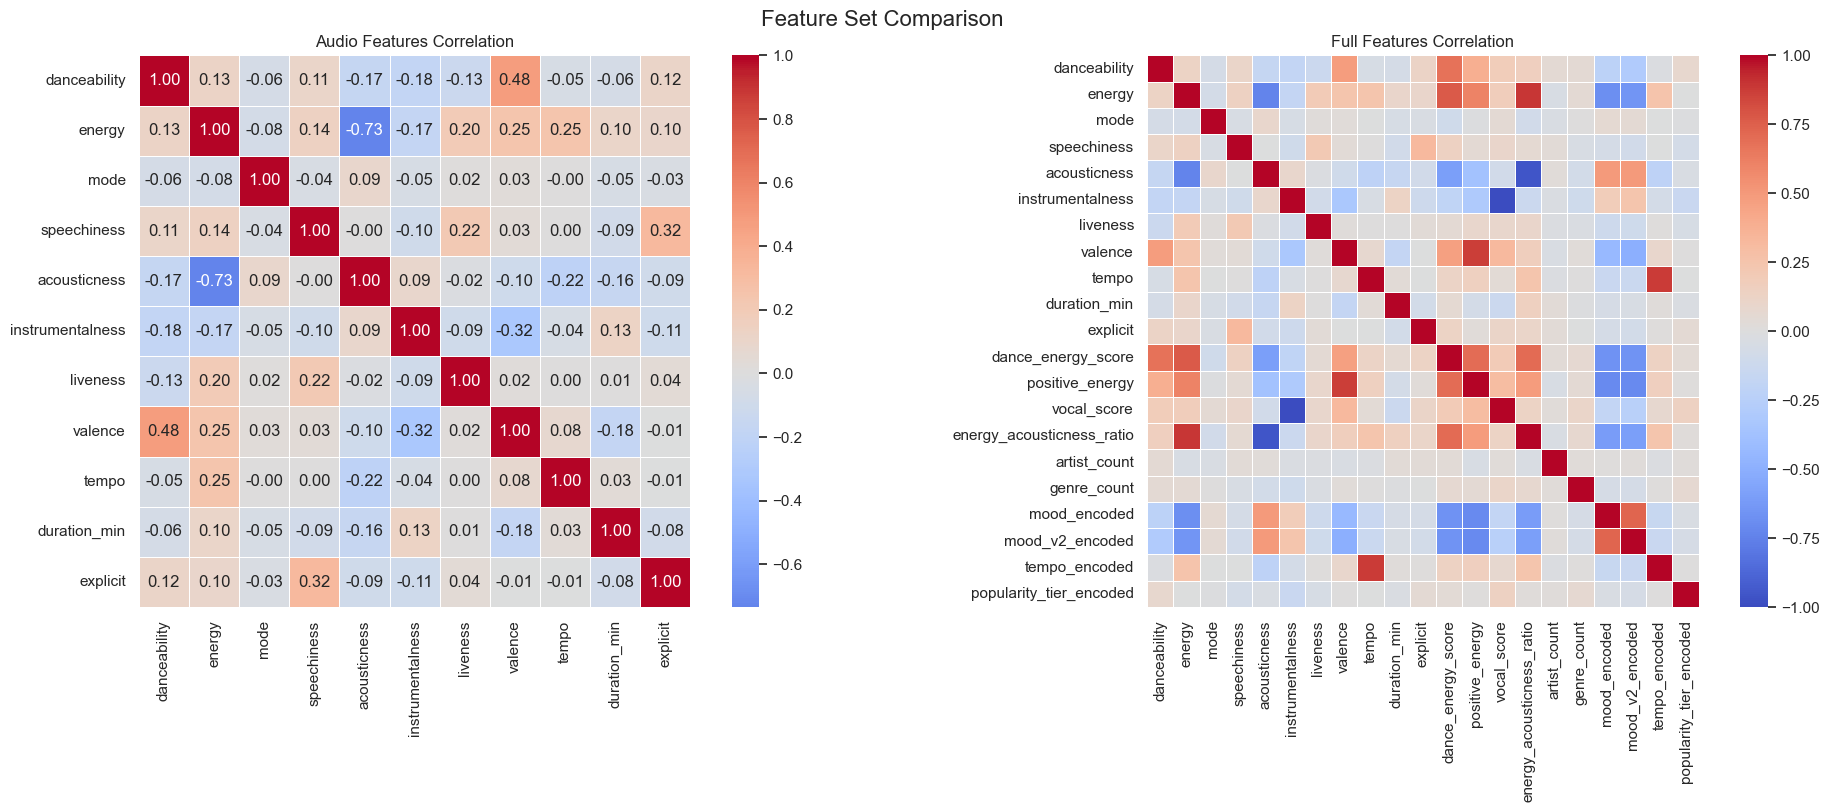

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# audio features correlation
corr_audio = df[audio_features].corr()
sns.heatmap(corr_audio, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Audio Features Correlation')

# full features correlation (without annotations for clarity)
corr_full = df[full_features].corr()
sns.heatmap(corr_full, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Full Features Correlation')

plt.suptitle('Feature Set Comparison', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/feature_set_comparison.png', bbox_inches='tight')
plt.show()

# Section 8 - Feature Importance Preview

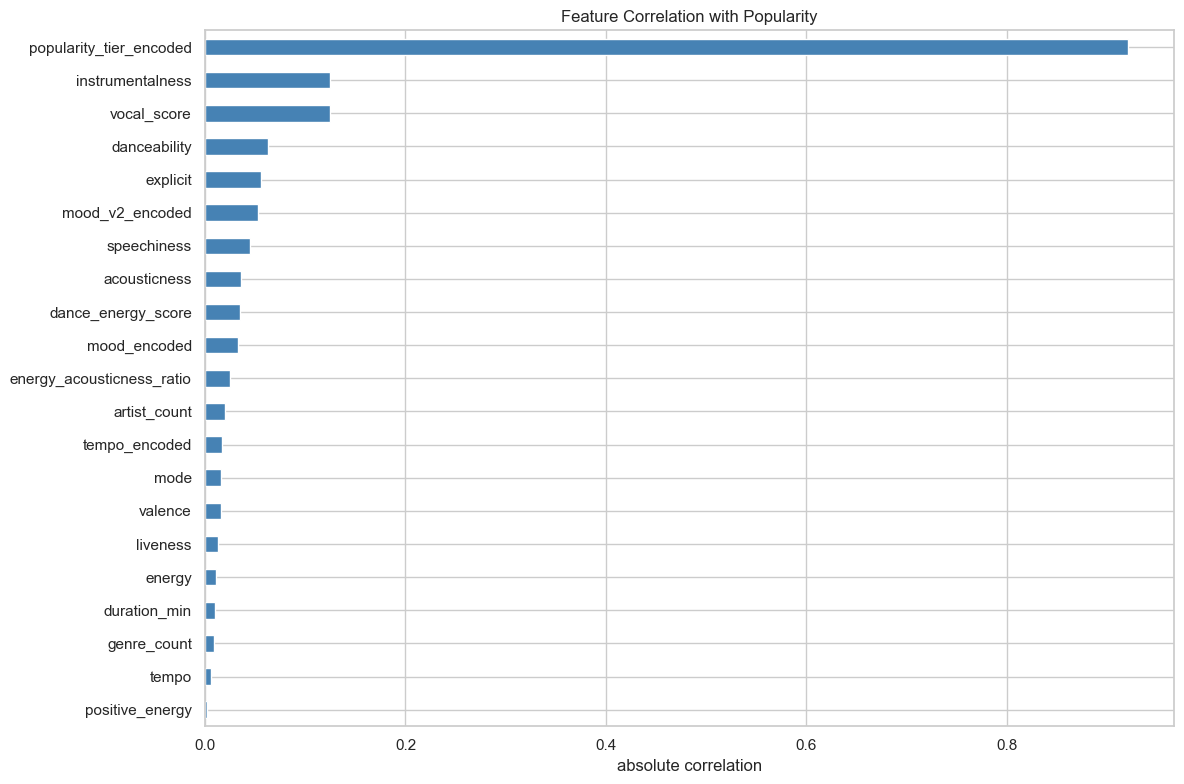

popularity_tier_encoded      0.920886
instrumentalness             0.124998
vocal_score                  0.124998
danceability                 0.062615
explicit                     0.055740
mood_v2_encoded              0.052743
speechiness                  0.045130
acousticness                 0.035803
dance_energy_score           0.034738
mood_encoded                 0.032872
energy_acousticness_ratio    0.024447
artist_count                 0.020267
tempo_encoded                0.017138
mode                         0.016342
valence                      0.015663
liveness                     0.013309
energy                       0.010594
duration_min                 0.009836
genre_count                  0.009008
tempo                        0.005819
positive_energy              0.001772
Name: popularity, dtype: float64


In [9]:
correlations = df[full_features + ['popularity']].corr()['popularity'].drop('popularity')
correlations = correlations.abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlations.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Popularity')
plt.xlabel('absolute correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/features/feature_importance_preview.png', bbox_inches='tight')
plt.show()

print(correlations)

# Section 9 - Scaled Features Verification

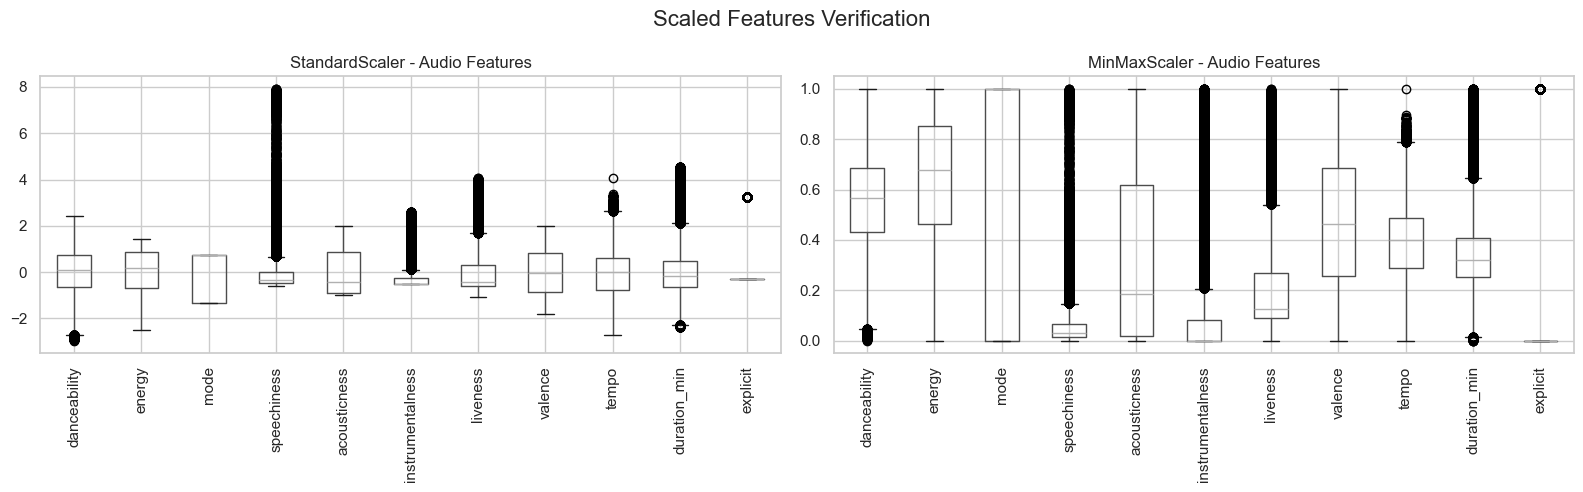

In [10]:
df_standard = pd.read_csv('../data/processed/featured_full_standard.csv')
df_minmax = pd.read_csv('../data/processed/featured_full_minmax.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_standard[audio_features].boxplot(ax=axes[0])
axes[0].set_title('StandardScaler - Audio Features')
axes[0].tick_params(axis='x', rotation=90)

df_minmax[audio_features].boxplot(ax=axes[1])
axes[1].set_title('MinMaxScaler - Audio Features')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle('Scaled Features Verification', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/features/scaled_features_verification.png', bbox_inches='tight')
plt.show()

# Section 10 - TF-IDF Input Verification

sample tfidf_input by genre:

rock songs:
['acoustic rock calm fast charttoppers', 'acoustic rock calm fast emerging', 'acoustic rock happy medium emerging']

hip-hop songs:
['alternative hip-hop calm slow charttoppers', 'alternative hip-hop happy fast emerging', 'alternative hip-hop happy medium emerging']

classical songs:
['ambient classical sad medium charttoppers', 'ambient classical sad medium emerging', 'ambient classical sad fast emerging']


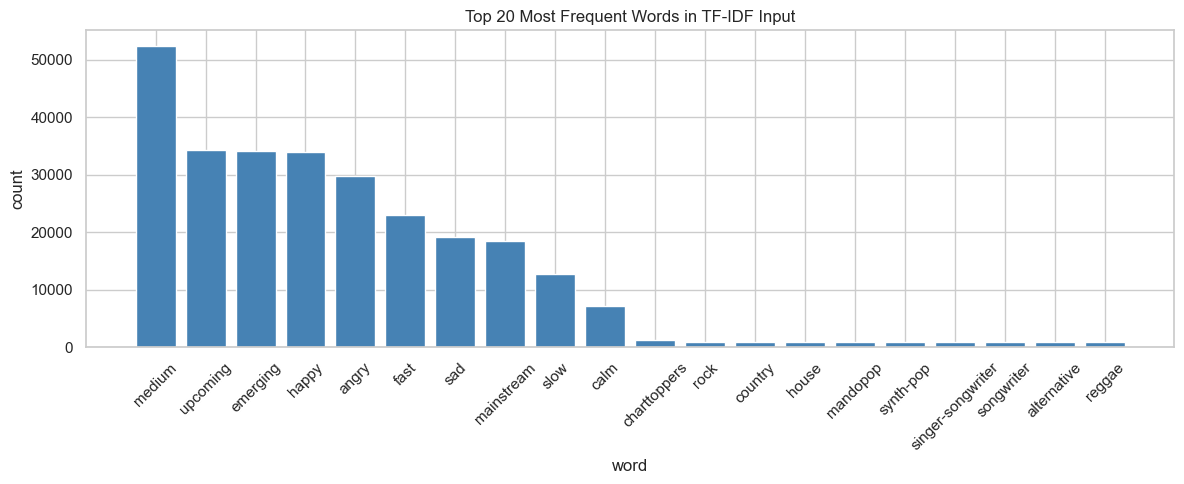

In [11]:
from collections import Counter

print('sample tfidf_input by genre:')
print('\nrock songs:')
print(df[df['track_genre'].str.contains('rock')]['tfidf_input'].head(3).tolist())
print('\nhip-hop songs:')
print(df[df['track_genre'].str.contains('hip-hop')]['tfidf_input'].head(3).tolist())
print('\nclassical songs:')
print(df[df['track_genre'].str.contains('classical')]['tfidf_input'].head(3).tolist())

# word frequency
all_words = ' '.join(df['tfidf_input']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Most Frequent Words in TF-IDF Input')
plt.xlabel('word')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/features/tfidf_word_frequency.png', bbox_inches='tight')
plt.show()

# Save Feature Importance to Table

In [12]:
correlations.to_csv('../reports/tables/feature_importance_preview.csv')
print('saved to reports/tables/feature_importance_preview.csv')

saved to reports/tables/feature_importance_preview.csv


# EDA Features Summary

In [14]:
print('='*50)
print('EDA FEATURES SUMMARY')
print('='*50)

print('\n--- New Features Verified ---')
print('mood v1 (0.5) → more balanced distribution → preferred')
print('mood v2 (0.4) → happy dominated → less balanced')
print('tempo_category → medium dominates (59%) → natural')
print('popularity_tier → tiers verified correctly')
print('artist_count → mostly 1-2 artists, few outliers (valid)')
print('genre_count → mostly 1 genre, few multi-genre')
print('duration_min → clean bell curve 2-5 minutes')

print('\n--- Combined Features Verified ---')
print('dance_energy_score → clean bell curve ')
print('positive_energy    → right skewed ')
print('vocal_score        → spike at 1.0 (most songs vocal) ')
print('energy_acousticness_ratio → bimodal, bounded ')

print('\n--- Key Findings ---')
print('1. vocal_score perfectly redundant with instrumentalness (-1.00)')
print('2. energy_acousticness_ratio highly correlated with acousticness (-0.96)')
print('3. mood v1 (threshold 0.5) better than v2 (threshold 0.4)')
print('4. popularity_tier_encoded most correlated with popularity (0.91)')
print('5. explicit binary feature scales poorly with MinMaxScaler')
print('6. TF-IDF input verified — meaningful text per song')

print('\n--- Model Experiment Recommendations ---')
print('experiment 1 → audio_features only')
print('experiment 2 → full_features')
print('experiment 3 → full_features minus redundant (vocal_score, energy_acousticness_ratio)')
print('scaling 1    → StandardScaler')
print('scaling 2    → MinMaxScaler')

print('\n--- Saved Files ---')
print('reports/figures/features/ → 8 visualizations')
print('reports/tables/feature_importance_preview.csv')

EDA FEATURES SUMMARY

--- New Features Verified ---
mood v1 (0.5) → more balanced distribution → preferred
mood v2 (0.4) → happy dominated → less balanced
tempo_category → medium dominates (59%) → natural
popularity_tier → tiers verified correctly
artist_count → mostly 1-2 artists, few outliers (valid)
genre_count → mostly 1 genre, few multi-genre
duration_min → clean bell curve 2-5 minutes

--- Combined Features Verified ---
dance_energy_score → clean bell curve 
positive_energy    → right skewed 
vocal_score        → spike at 1.0 (most songs vocal) 
energy_acousticness_ratio → bimodal, bounded 

--- Key Findings ---
1. vocal_score perfectly redundant with instrumentalness (-1.00)
2. energy_acousticness_ratio highly correlated with acousticness (-0.96)
3. mood v1 (threshold 0.5) better than v2 (threshold 0.4)
4. popularity_tier_encoded most correlated with popularity (0.91)
5. explicit binary feature scales poorly with MinMaxScaler
6. TF-IDF input verified — meaningful text per song

